<a href="https://colab.research.google.com/github/AnanthaKrishna07/Loan-Approval-Prediction-System/blob/main/LoanApproval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [32]:
df = pd.read_csv('loan_approval_dataset.csv')

df.columns = df.columns.str.strip()

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


/tmp/ipykernel_4013/1068417496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='cibil_score', data=df, palette='muted')


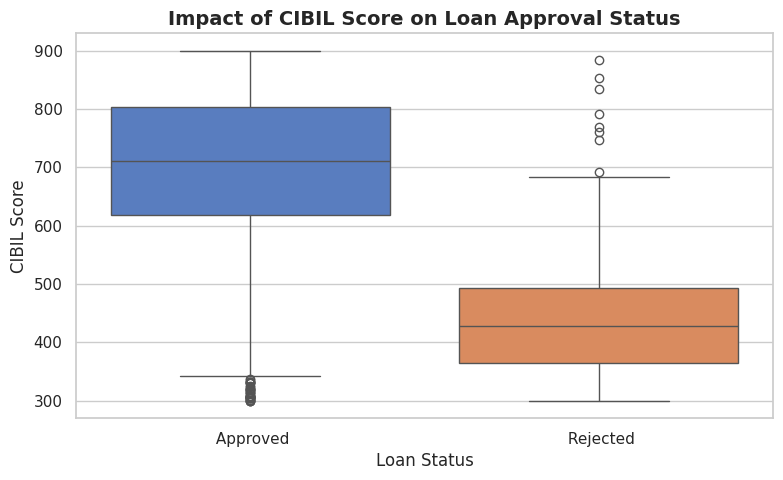

In [34]:
plt.figure(figsize=(9, 5))

sns.boxplot(x='loan_status', y='cibil_score', data=df, palette='muted')

plt.title('Impact of CIBIL Score on Loan Approval Status', fontsize=14, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('CIBIL Score', fontsize=12)

plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

df[['education', 'self_employed', 'loan_status']].head(3)

,education,self_employed,loan_status
0,0,0,0
1,1,1,1
2,0,0,1


In [36]:
X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']

print("Features (X) and Target (y) split successfully!")
print(f"Features DataFrame Shape (X): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target Vector Shape (y): {y.shape[0]} rows")

Features (X) and Target (y) split successfully!
Features DataFrame Shape (X): 4269 rows, 11 columns
Target Vector Shape (y): 4269 rows


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train-Test Split complete!")

print(f"Training Features: {X_train.shape} | Testing Features: {X_test.shape}")
print(f"Training Targets:  {y_train.shape}   | Testing Targets:  {y_test.shape}")

Train-Test Split complete!
Training Features: (3415, 11) | Testing Features: (854, 11)
Training Targets:  (3415,)   | Testing Targets:  (854,)


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Training Complete!")

Model Training Complete!


In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Overall Model Accuracy: 98.36%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [40]:
import joblib

joblib.dump(model, 'loan_prediction_model.pkl')

print("Model saved successfully as 'loan_prediction_model.pkl'!")

Model saved successfully as 'loan_prediction_model.pkl'!


In [41]:
import numpy as np
import pandas as pd
import joblib

loaded_model = joblib.load('loan_prediction_model.pkl')

no_of_dependents = 2 #@param {type:"slider", min:0, max:5, step:1}
education = "Graduate" #@param ["Graduate", "Not Graduate"]
self_employed = "No" #@param ["No", "Yes"]
income_annum = 5000000 #@param {type:"number"}
loan_amount = 15000000 #@param {type:"number"}
loan_term = 12 #@param {type:"slider", min:2, max:20, step:2}
cibil_score = 750 #@param {type:"slider", min:300, max:900, step:10}
residential_assets_value = 4000000 #@param {type:"number"}
commercial_assets_value = 2000000 #@param {type:"number"}
luxury_assets_value = 6000000 #@param {type:"number"}
bank_asset_value = 3000000 #@param {type:"number"}

edu_encoded = 0 if education == "Graduate" else 1
emp_encoded = 1 if self_employed == "Yes" else 0

input_data = pd.DataFrame([[
    no_of_dependents, edu_encoded, emp_encoded, income_annum,
    loan_amount, loan_term, cibil_score, residential_assets_value,
    commercial_assets_value, luxury_assets_value, bank_asset_value
]], columns=['no_of_dependents', 'education', 'self_employed', 'income_annum',
             'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
             'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'])

prediction = loaded_model.predict(input_data)

print("\n" + "="*40)
print("       BANK DECISION ENGINE OUTPUT       ")
print("="*40)
if prediction[0] == 0:
    print("STATUS: LOAN APPROVED")
    print("Decision Basis: Applicant meets structural asset risk standards.")
else:
    print("STATUS: LOAN REJECTED")
    print("Decision Basis: High credit default risk profile or insufficient collateral.")
print("="*40)


       BANK DECISION ENGINE OUTPUT       
STATUS: LOAN APPROVED
Decision Basis: Applicant meets structural asset risk standards.
